In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd 

In [3]:
r = lambda x, y: np.sqrt(x**2 + y**2)

# indice de refraccion de aproximacion eikonal
n = lambda x, y, rmax: 1/ (1 - rmax/ r(x, y))

# Falctor de correccion
corr = lambda x, y, rmax: np.abs(1 - 9/8 * (rmax/ r(x, y))**2)


Las ecuaciones que describen la trayectoria $(x, y)$ y la velocidad $(v_x, v_y)$ de un rayo en esta aproximación viene dada por: 

$$
\frac{dx}{dt} = \frac{v_x}{n(x, y)} \quad \wedge \quad \frac{dy}{dt} = \frac{v_y}{n(x,y)}
$$

y:

$$
\frac{d\, v_x}{dt} = \frac{\partial }{\partial x} n(x, y) \quad \wedge \quad \frac{d\,v_y}{dt} = \frac{\partial}{\partial y} n(x, y)
$$

In [4]:
# definimos las ecuaciones diferenciales de la trayectoria de la luz

def refindex(x, y, A=1.0):
    eps = 1e-6       # correccion para evitar singularidades numéricas
    nx = rp0 = np.sqrt(x**2 + y**2)
    n = 1 / (1 - A / (rp0 + eps))
    fac = np.abs((1 - 9*(A / rp0)**2 / 8))
    nx = -fac * n**2 * A * x / (rp0 + eps)**3
    ny = -fac * n**2 * A * y / (rp0 + eps)**3
    return [n, nx, ny]

def flow_deriv(x_y_z, tspan):
    x, y, z, w = x_y_z
    [n, nx, ny] = refindex(x, y)
    yp = np.zeros(shape=(4,))
    yp[0] = z / n
    yp[1] = w / n
    yp[2] = nx
    yp[3] = ny
    return yp


## **integración de rayos en el plano $x-y$**

In [8]:
N = 1000 # numero de posiciones iniciales a generar
R = 70 # radio sugerido

# Generamos posiciones iniciales aleatorias dentro de un círculo de radio R
theta = np.random.uniform(0, 2*np.pi, N)
r = R * np.sqrt(np.random.uniform(0, 1, N))

# posiciones cartesianas en el plano y-z
y = r * np.cos(theta)
z = r * np.sin(theta)
x = np.zeros(N)  # eje x

# lo convertimos a coordenadas cilindricas
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arctan2(y, x)


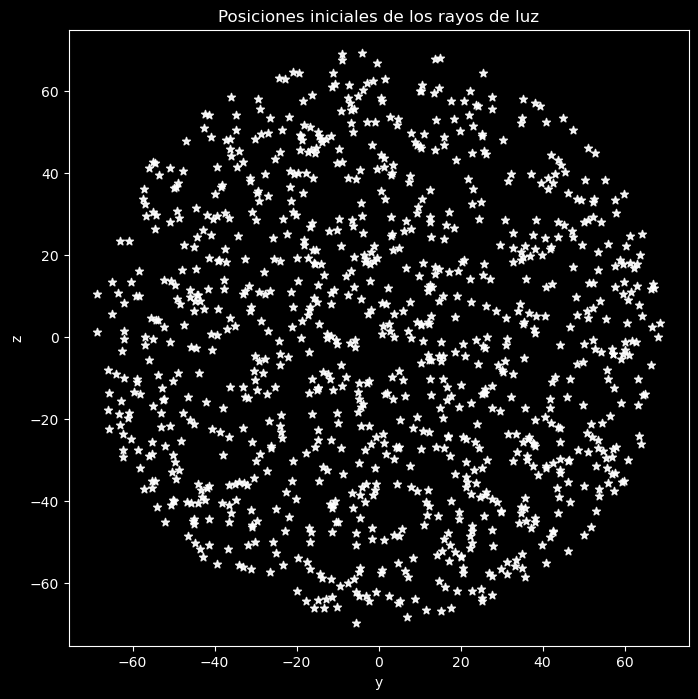

In [10]:
# visualizacion de los puntos en el plano

plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(y, z, s=35, c='white', marker='*', alpha=0.9)
plt.title('Posiciones iniciales de los rayos de luz', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
plt.show()

## **Integración de rayos en plano $x-y$**

In [ ]:
# inicializamos el proceso de integración para la aproximacion eikonal
